# Combine Two YOLO Models on the Same NFL Frame (No Homography Yet)

This notebook:

- Loads **two trained YOLO models**:
  - A *field model* (detects hashes, numbers, etc.)
  - A *player model* (detects players)
- Runs **both models on the same input image**
- Extracts detections from each
- Combines the outputs into a single Python structure

> This version does **not** do any homography / field-coordinate mapping.  
> It only combines raw pixel-space detections.


In [22]:
import os
import sys
from pathlib import Path

import cv2
import numpy as np
from ultralytics import YOLO

print("Python:", sys.version)
print("CWD:", os.getcwd())

# ========================
# CONFIG: UPDATE THESE PATHS
# ========================

# Path to trained YOLO models
# Make sure these point to your actual best.pt files (usually under runs/train/.../weights/best.pt)
FIELD_MODEL_WEIGHTS = "/Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/runs/detect/football_yolo11n2/weights/best.pt"     # field / hash / number model
PLAYER_MODEL_WEIGHTS = "/Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/runs/detect/football_positions3/weights/best.pt" # player detector

# Path to an example NFL frame
IMAGE_PATH = "/Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/Football Player Detection.v7i.yolov11/test/images/57512_002838_Sideline_frame59_jpg.rf.a341e3ca674fc7ccf80eb81a74772ca1.jpg"  # e.g. "test/images/frame_0001.jpg"

print("Field model weights:", FIELD_MODEL_WEIGHTS)
print("Player model weights:", PLAYER_MODEL_WEIGHTS)
print("Example image path:", IMAGE_PATH)

Python: 3.9.6 (default, Oct 17 2025, 17:15:53) 
[Clang 17.0.0 (clang-1700.4.4.1)]
CWD: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier
Field model weights: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/runs/detect/football_yolo11n2/weights/best.pt
Player model weights: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/runs/detect/football_positions3/weights/best.pt
Example image path: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/Football Player Detection.v7i.yolov11/test/images/57512_002838_Sideline_frame59_jpg.rf.a341e3ca674fc7ccf80eb81a74772ca1.jpg


In [23]:
# ========================
# Load YOLO Models
# ========================

if not os.path.exists(FIELD_MODEL_WEIGHTS):
    print(f"⚠️ Field model weights not found at: {FIELD_MODEL_WEIGHTS}")
else:
    print(f"✅ Found field model at: {FIELD_MODEL_WEIGHTS}")

if not os.path.exists(PLAYER_MODEL_WEIGHTS):
    print(f"⚠️ Player model weights not found at: {PLAYER_MODEL_WEIGHTS}")
else:
    print(f"✅ Found player model at: {PLAYER_MODEL_WEIGHTS}")

field_model = YOLO(FIELD_MODEL_WEIGHTS)
player_model = YOLO(PLAYER_MODEL_WEIGHTS)

print("Field model classes:", field_model.names)
print("Player model classes:", player_model.names)

✅ Found field model at: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/runs/detect/football_yolo11n2/weights/best.pt
✅ Found player model at: /Users/lucaspedemonte/Documents/VSCode/NFL_Play_Classifier/NFL_Play_Outcome_Classifier/runs/detect/football_positions3/weights/best.pt
Field model classes: {0: 'ball', 1: 'five_hash', 2: 'hash', 3: 'marker', 4: 'number', 5: 'player', 6: 'pylon', 7: 'ref'}
Player model classes: {0: 'C', 1: 'DB', 2: 'LB', 3: 'QB', 4: 'SKILL'}


In [24]:
# ========================
# Helper: Convert YOLO Results to Dicts
# ========================

def extract_detections(result):
    """Convert a YOLO result object into a list of simple dicts.
    
    Each dict:
    {
        'class_id': int,
        'class_name': str,
        'confidence': float,
        'bbox': (x1, y1, x2, y2)
    }
    """
    det_list = []
    names = result.names
    
    for box in result.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        det_list.append({
            "class_id": cls_id,
            "class_name": names[cls_id],
            "confidence": conf,
            "bbox": (x1, y1, x2, y2),
        })
    return det_list

In [25]:
# ========================
# Run Both Models on the Same Image
# ========================

# Load the image
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load image at: {IMAGE_PATH}")

# Run the field model
print("Running field model...")
field_results = field_model(img)[0]   # first (and only) image in batch
field_dets = extract_detections(field_results)
print(f"Field detections: {len(field_dets)}")

# Run the player model
print("\nRunning player model...")
player_results = player_model(img)[0]
player_dets = extract_detections(player_results)
print(f"Player detections: {len(player_dets)}")

# Combine outputs into a single structure
combined_output = {
    "field": field_dets,
    "players": player_dets,
}

combined_output

Running field model...

0: 736x1280 11 five_hashs, 45 hashs, 2 markers, 6 numbers, 84.6ms
Speed: 7.6ms preprocess, 84.6ms inference, 2.3ms postprocess per image at shape (1, 3, 736, 1280)
Field detections: 64

Running player model...

0: 384x640 1 C, 3 DBs, 8 LBs, 1 QB, 1 SKILL, 19.8ms
Speed: 1.0ms preprocess, 19.8ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Player detections: 14


{'field': [{'class_id': 2,
   'class_name': 'hash',
   'confidence': 0.9267293810844421,
   'bbox': (723.3321533203125,
    244.34329223632812,
    736.6458740234375,
    257.8368835449219)},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8875434398651123,
   'bbox': (1165.7470703125,
    312.38525390625,
    1192.673828125,
    319.7078857421875)},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8866279721260071,
   'bbox': (999.22509765625,
    289.9239501953125,
    1024.51220703125,
    297.90008544921875)},
  {'class_id': 3,
   'class_name': 'marker',
   'confidence': 0.8658434152603149,
   'bbox': (92.326171875,
    603.7049560546875,
    122.09774780273438,
    700.5355224609375)},
  {'class_id': 2,
   'class_name': 'hash',
   'confidence': 0.8386999368667603,
   'bbox': (421.409423828125,
    201.78955078125,
    436.71331787109375,
    214.234130859375)},
  {'class_id': 1,
   'class_name': 'five_hash',
   'confidence': 0.8329778909683228,

Combined detections summary:
{'field': [{'bbox': (723.3321533203125,
                     244.34329223632812,
                     736.6458740234375,
                     257.8368835449219),
            'class_id': 2,
            'class_name': 'hash',
            'confidence': 0.9267293810844421},
           {'bbox': (1165.7470703125,
                     312.38525390625,
                     1192.673828125,
                     319.7078857421875),
            'class_id': 1,
            'class_name': 'five_hash',
            'confidence': 0.8875434398651123},
           {'bbox': (999.22509765625,
                     289.9239501953125,
                     1024.51220703125,
                     297.90008544921875),
            'class_id': 1,
            'class_name': 'five_hash',
            'confidence': 0.8866279721260071},
           {'bbox': (92.326171875,
                     603.7049560546875,
                     122.09774780273438,
                     700.5355224609375),
     

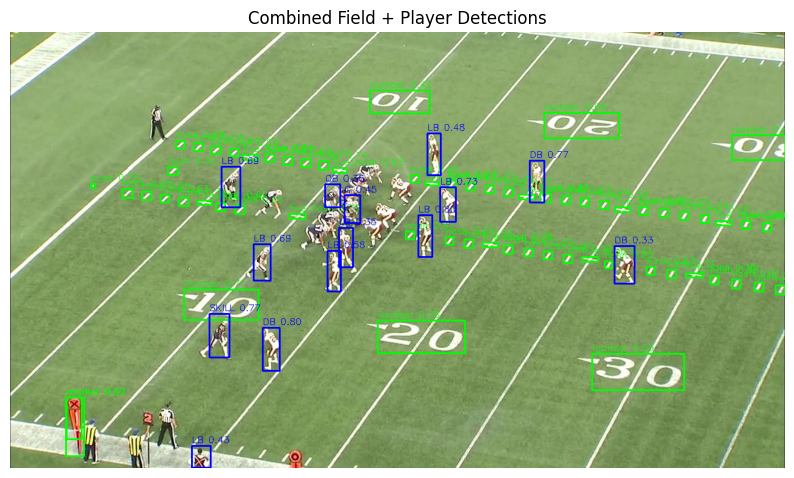

In [26]:
# ========================
# Optional: Pretty Print & Visualize Detections
# ========================

from pprint import pprint
import matplotlib.pyplot as plt

print("Combined detections summary:")
pprint(combined_output)

# Draw both sets of detections on the image for visualization
vis = img.copy()

# Draw field detections in one color
for det in combined_output["field"]:
    x1, y1, x2, y2 = map(int, det["bbox"])
    label = f"{det['class_name']} {det['confidence']:.2f}"
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, label, (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# Draw player detections in another color
for det in combined_output["players"]:
    x1, y1, x2, y2 = map(int, det["bbox"])
    label = f"{det['class_name']} {det['confidence']:.2f}"
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(vis, label, (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

# Convert BGR (OpenCV) -> RGB (matplotlib)
vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(vis_rgb)
plt.axis("off")
plt.title("Combined Field + Player Detections")
plt.show()

## Next Steps

From here you can:

- Loop over many frames and collect `combined_output` into a list or a CSV.
- Add homography later to convert pixel `(x, y)` centers into field coordinates in yards.
- Use the combined detections as input features to your **play outcome classifier**.

To adapt this to a folder of images, you can replace `IMAGE_PATH` with a loop over a directory:
```python
from glob import glob

for path in glob("frames/*.jpg"):
    # run the same pipeline on each image
    ...
```